In [143]:
import numpy as np
import pandas as pd
import re

import warnings
warnings.filterwarnings('ignore')

In [61]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns', None)

In [63]:
df = pd.read_csv('/home/puru/Documents/House Price Prediction/STEP - 2 (Data Cleaning)/STEP - 1/Merge House and Flats/STEP - 2/gurgaon_properties_cleaned_v1.csv')

In [65]:
df.duplicated().sum()

0

In [67]:
df.head(5)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,not available,0.0,West,5 to 10 Year Old,"['Standard chartered ATM', 'Icici bank ATM', '...","['1 Water Purifier', '3 Fan', '1 Exhaust Fan',...","['Maintenance Staff', 'Swimming Pool', 'Park']"
1,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,"servant room,pooja room",4.0,North-East,1 to 5 Year Old,"['Guru dronacharya metro station', 'Dlf phase ...","['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Feng Shui / Vaastu Compliant', 'Private Gard..."
2,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,"study room,servant room",2.0,North-East,1 to 5 Year Old,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Cour...","['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe..."
3,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,not available,12.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...",[],"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
4,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,pooja room,5.0,South-West,1 to 5 Year Old,"['Bigbasket SPR 5K DS', 'iON Digital Zone, DPG...",NaN,"['Security / Fire Alarm', 'Lift(s)', 'Maintena..."


## `1.` areaWithType

In [70]:
df.sample(10)[['price','area','areaWithType']]

,price,area,areaWithType
2749,6.30,7000.0,Built Up area: 7000 (650.32 sq.m.)Carpet area:...
2801,0.40,595.0,Carpet area: 594.52 (55.23 sq.m.)
115,1.28,1877.0,Super Built up area 1877(174.38 sq.m.)Built Up...
1803,0.35,545.0,Carpet area: 545 (50.63 sq.m.)
462,18.00,4518.0,Plot area 502(419.74 sq.m.)
1252,1.50,1850.0,Super Built up area 1850(171.87 sq.m.)
3324,4.50,3154.0,Super Built up area 3154(293.02 sq.m.)
2711,1.35,1890.0,Built Up area: 1820 (169.08 sq.m.)
2393,1.80,1314.0,Carpet area: 1310 (121.7 sq.m.)
2738,2.98,2047.0,Super Built up area 2047(190.17 sq.m.)


In [72]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area \d+\((\d+\.?\d*) sq\.m\.\)', text)
    if match:
        return float(match.group(1))
    return None

In [74]:
# This function extracts the Built up area and carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'.*?\((\d+\.?\d*)\s*sq\.m\.\)', text)
    if match:
        return float(match.group(1))
    return None

In [76]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df['super_built_up_area'].apply(lambda x: round(x * 10.7639, 2) if pd.notna(x) else np.nan)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df['built_up_area'].apply(lambda x: round(x * 10.7639, 2) if pd.notna(x) else np.nan)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df['carpet_area'].apply(lambda x: round(x * 10.7639, 2) if pd.notna(x) else np.nan)

In [78]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,2.40,flat,2400.0,Carpet area: 2400 (222.97 sq.m.),NaN,NaN,2400.03
1,10.50,house,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,NaN,2700.02,2429.95
2,2.36,flat,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,1650.00,NaN,1399.95
3,2.25,flat,1700.0,Super Built up area 1700(157.94 sq.m.),1700.05,NaN,NaN
4,0.60,flat,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,599.98,NaN,513.98
5,1.40,flat,1780.0,Super Built up area 1780(165.37 sq.m.),1780.03,NaN,NaN
6,7.00,house,3000.0,Plot area 2400(222.97 sq.m.)Built Up area: 340...,NaN,3399.99,3000.01
7,0.32,house,145.0,Built Up area: 145 (13.47 sq.m.),NaN,144.99,NaN
8,1.10,flat,1300.0,Super Built up area 1300(120.77 sq.m.)Carpet a...,1299.96,NaN,788.03
9,0.87,flat,1621.0,Super Built up area 1360(126.35 sq.m.),1360.02,NaN,NaN


In [80]:
df.duplicated().sum()

0

In [82]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(531, 7)

In [84]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,10.50,house,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,NaN,2700.02,2429.95
6,7.00,house,3000.0,Plot area 2400(222.97 sq.m.)Built Up area: 340...,NaN,3399.99,3000.01
12,0.49,house,436.0,Plot area 360(33.45 sq.m.),NaN,NaN,NaN
16,2.25,house,1440.0,Plot area 160(133.78 sq.m.),NaN,NaN,NaN
17,5.50,house,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,NaN,25649.94,20250.02


In [86]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    17
price_per_sqft           17
area                     17
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1048
agePossession             1
nearbyLocations         170
furnishDetails          946
features                599
super_built_up_area    1824
built_up_area          2541
carpet_area            1828
dtype: int64

In [88]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [90]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
12,0.49,house,436.0,Plot area 360(33.45 sq.m.),NaN,NaN,NaN
16,2.25,house,1440.0,Plot area 160(133.78 sq.m.),NaN,NaN,NaN
21,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
22,NaN,house,NaN,Plot area 670(560.21 sq.m.),NaN,NaN,NaN
29,9.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN


In [92]:
all_nan_df.shape

(578, 7)

In [94]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [96]:
# Function to extract plot area from 'areaWithType' column

def extract_plot_area(area_with_type):
    match = re.search(r'Plot area \d+\((\d+\.?\d*) sq\.m\.\)', area_with_type)
    return float(match.group(1)) if match else None

In [98]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)
all_nan_df['built_up_area'] = all_nan_df['built_up_area'].apply(lambda x: round(x * 10.7639, 2) if pd.notna(x) else np.nan)

In [100]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
12,0.49,house,436.0,Plot area 360(33.45 sq.m.),NaN,360.05,NaN
16,2.25,house,1440.0,Plot area 160(133.78 sq.m.),NaN,1439.99,NaN
21,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.05,NaN
22,NaN,house,NaN,Plot area 670(560.21 sq.m.),NaN,6030.04,NaN
29,9.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.02,NaN
31,10.30,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.04,NaN
37,7.69,house,3195.0,Plot area 355(296.83 sq.m.),NaN,3195.05,NaN
43,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.04,NaN
52,2.10,house,1215.0,Plot area 135(112.88 sq.m.),NaN,1215.03,NaN
54,3.60,house,1728.0,Plot area 192(160.54 sq.m.),NaN,1728.04,NaN


In [102]:
rows_to_update = [1285,1767,2024,2203,2295,2400,2419,2798,2830,3013,3336,3499,1628]
new_values = [569,2072,1508,958,1827,1440,1056,1560,1732,2368,1252,3462,2588]
all_nan_df.loc[rows_to_update, 'super_built_up_area'] = new_values

In [104]:
rows_to_update = [471,528,724,920,1045,1392,1436,1479,1560,1568,1573,1718,2224,2323,2798,2822,2830,2968,2998,3013,3505,802]
new_values = [1370,995,7603,1167,990,904,823,832,990,835,8116,925,1344,1159,925,822,1166,822,12648,1722,2152,635]
all_nan_df.loc[rows_to_update, 'carpet_area'] = new_values

In [106]:
rows_to_update = [608,770, 806,1045, 1573, 2745, 3612,2323,2864,2933,3013,3017,3057,744,802,1718]
new_values = [3660,5608, 4521,1044, 8116, 538, 1722,1393,807,1337,1830,1783,1070,1185,645,1270]
all_nan_df.loc[rows_to_update, 'built_up_area'] = new_values

In [108]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
12,0.49,house,436.0,Plot area 360(33.45 sq.m.),NaN,360.05,NaN
16,2.25,house,1440.0,Plot area 160(133.78 sq.m.),NaN,1439.99,NaN
21,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.05,NaN
22,NaN,house,NaN,Plot area 670(560.21 sq.m.),NaN,6030.04,NaN
29,9.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.02,NaN
31,10.30,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.04,NaN
37,7.69,house,3195.0,Plot area 355(296.83 sq.m.),NaN,3195.05,NaN
43,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.04,NaN
52,2.10,house,1215.0,Plot area 135(112.88 sq.m.),NaN,1215.03,NaN
54,3.60,house,1728.0,Plot area 192(160.54 sq.m.),NaN,1728.04,NaN


In [114]:
# update the original dataframe
df.update(all_nan_df)

In [116]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    17
price_per_sqft           17
area                     17
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1048
agePossession             1
nearbyLocations         170
furnishDetails          946
features                599
super_built_up_area    1811
built_up_area          1989
carpet_area            1806
dtype: int64

In [118]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,not available,0.0,West,5 to 10 Year Old,"['Standard chartered ATM', 'Icici bank ATM', '...","['1 Water Purifier', '3 Fan', '1 Exhaust Fan',...","['Maintenance Staff', 'Swimming Pool', 'Park']",NaN,NaN,2400.03
1,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,"servant room,pooja room",4.0,North-East,1 to 5 Year Old,"['Guru dronacharya metro station', 'Dlf phase ...","['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,2700.02,2429.95
2,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,"study room,servant room",2.0,North-East,1 to 5 Year Old,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Cour...","['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",1650.00,NaN,1399.95
3,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,not available,12.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...",[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...",1700.05,NaN,NaN
4,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,pooja room,5.0,South-West,1 to 5 Year Old,"['Bigbasket SPR 5K DS', 'iON Digital Zone, DPG...",NaN,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",599.98,NaN,513.98


## 2.additionalRoom

In [120]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1516
servant room                                      688
study room                                        243
others                                            219
pooja room                                        164
store room                                         97
study room,servant room                            97
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                55
pooja room,study room,servant room,others          54
pooja room,study room,servant room                 53
servant room,pooja room                            38
servant room,store room                            31
study room,others                                  26
pooja room,study room                              21
pooja room,others                                  16
pooja room,store room                              15
pooja room,st

In [122]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [124]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
9,others,0,0,0,0,1
1058,others,0,0,0,0,1
1473,not available,0,0,0,0,0
1417,servant room,0,1,0,0,0
2190,others,0,0,0,0,1


In [126]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,not available,0.0,West,5 to 10 Year Old,"['Standard chartered ATM', 'Icici bank ATM', '...","['1 Water Purifier', '3 Fan', '1 Exhaust Fan',...","['Maintenance Staff', 'Swimming Pool', 'Park']",NaN,NaN,2400.03,0,0,0,0,0
1,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,"servant room,pooja room",4.0,North-East,1 to 5 Year Old,"['Guru dronacharya metro station', 'Dlf phase ...","['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,2700.02,2429.95,0,1,0,1,0
2,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,"study room,servant room",2.0,North-East,1 to 5 Year Old,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Cour...","['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",1650.00,NaN,1399.95,1,1,0,0,0
3,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,not available,12.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...",[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...",1700.05,NaN,NaN,0,0,0,0,0
4,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,pooja room,5.0,South-West,1 to 5 Year Old,"['Bigbasket SPR 5K DS', 'iON Digital Zone, DPG...",NaN,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",599.98,NaN,513.98,0,0,0,1,0


## 3.agePossession

In [128]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1646
5 to 10 Year Old       563
0 to 1 Year Old        503
undefined              307
10+ Year Old           303
Under Construction      88
Within 6 months         67
Within 3 months         24
Dec 2023                20
By 2023                 17
By 2024                 16
Dec 2024                15
Mar 2024                12
Jan 2024                 7
Dec 2025                 7
Jun 2024                 7
Aug 2023                 6
Oct 2024                 6
Nov 2023                 5
By 2025                  4
Sep 2023                 4
Oct 2023                 4
Aug 2024                 4
Jan 2025                 3
Feb 2024                 3
Jul 2024                 3
May 2024                 3
Nov 2024                 3
Mar 2025                 2
Jul 2025                 2
Jun 2027                 2
Jul 2027                 2
Apr 2026                 2
Aug 2025                 2
Dec 2026                 2
Sep 2025                 2
Jan 2026      

In [130]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [132]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [134]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           594
Moderately Old         563
Undefined              308
Old Property           303
Under Construction     267
Name: count, dtype: int64

In [136]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,not available,0.0,West,Moderately Old,"['Standard chartered ATM', 'Icici bank ATM', '...","['1 Water Purifier', '3 Fan', '1 Exhaust Fan',...","['Maintenance Staff', 'Swimming Pool', 'Park']",NaN,NaN,2400.03,0,0,0,0,0
1,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,"servant room,pooja room",4.0,North-East,Relatively New,"['Guru dronacharya metro station', 'Dlf phase ...","['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,2700.02,2429.95,0,1,0,1,0
2,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,"study room,servant room",2.0,North-East,Relatively New,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Cour...","['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",1650.00,NaN,1399.95,1,1,0,0,0
3,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,not available,12.0,North-East,Relatively New,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...",[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...",1700.05,NaN,NaN,0,0,0,0,0
4,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,pooja room,5.0,South-West,Relatively New,"['Bigbasket SPR 5K DS', 'iON Digital Zone, DPG...",NaN,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",599.98,NaN,513.98,0,0,0,1,0


## 4.furnishDetails

In [139]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
2552,NaN,['Park']
496,"['7 Fan', '1 Exhaust Fan', '2 Geyser', '10 Lig...",NaN
2941,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Feng Shui / Vaastu Compliant', 'Security / F..."
144,"['2 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Centrally Air Conditioned', 'Water purifier'..."
2527,"['5 AC', '1 Modular Kitchen', 'No Bed', 'No Ch...","['Intercom Facility', 'Lift(s)', 'Swimming Poo..."


In [145]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [147]:
furnishings_df.shape

(3681, 19)

In [149]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

In [151]:
furnishings_df.sample(5)

,Sofa,Wardrobe,TV,Bed,Exhaust Fan,Modular Kitchen,Dining Table,Water Purifier,Fridge,Washing Machine,AC,Geyser,Chimney,Stove,Fan,Microwave,Light,Curtains
3229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
139,0,4,0,0,0,1,0,0,0,0,0,0,1,0,0,0,4,0
1680,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2666,0,6,0,0,0,0,0,0,0,0,4,0,1,1,0,0,0,0
817,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [153]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [155]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [157]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

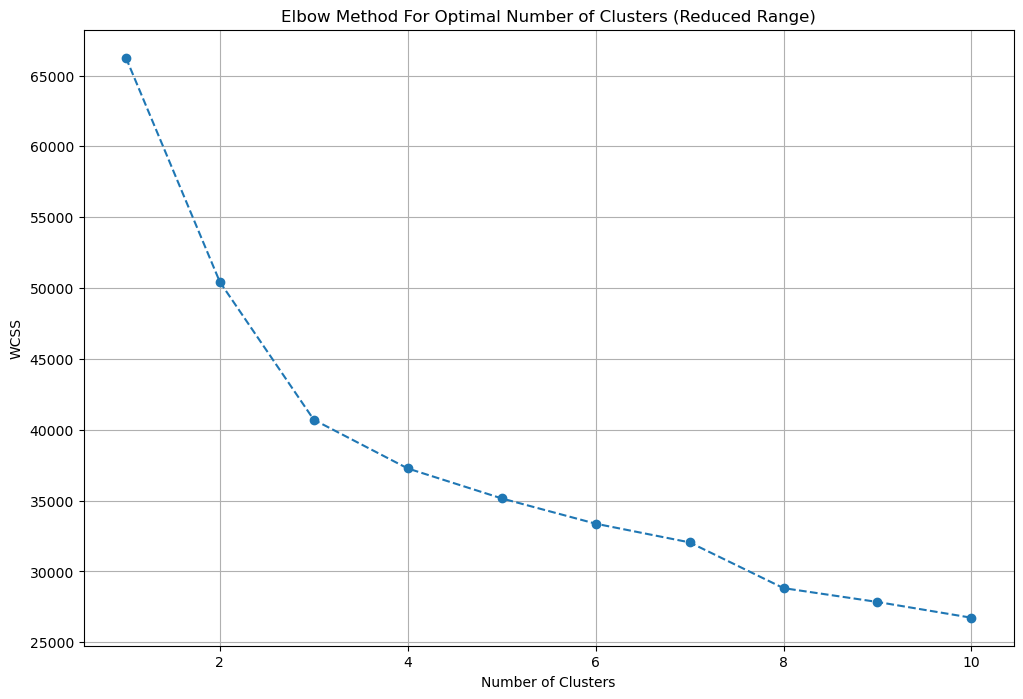

In [159]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [161]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [163]:
df = df.iloc[:,:-18]

In [165]:
df['furnishing_type'] = cluster_assignments

In [167]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
2540,"['4 Geyser', '9 Light', '1 AC', '1 Modular Kit...",1
2762,"['4 Wardrobe', '7 Fan', '4 Geyser', '11 Light'...",1
2066,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",0
649,NaN,0
2416,"['1 Fan', '1 Exhaust Fan', '1 Geyser', '1 Ligh...",0


## 5.features

In [169]:
df[['society','features']].sample(5)

,society,features
1971,huda floor,"['Water purifier', 'Centrally Air Conditioned'..."
1550,shree vardhman flora,"['Intercom Facility', 'Lift(s)', 'Maintenance ..."
2479,tulip purple,"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
3592,ramprastha skyz,['Natural Light']
2317,umang winter hills,"['Feng Shui / Vaastu Compliant', 'Security / F..."


In [171]:
df['features'].isnull().sum()

599

In [183]:
app_df = pd.read_csv('/home/puru/Documents/House Price Prediction/STEP - 1 (Data Gathering)/appartments.csv')
app_df.head()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."


In [185]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [187]:
temp_df = df[df['features'].isnull()]

In [189]:
temp_df.shape

(599, 26)

In [191]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [193]:
df.loc[temp_df.index,'features'] = x.values

In [195]:
df['features'].isnull().sum()

457

In [197]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [199]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [201]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
3091,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
387,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
3145,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
3608,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
1472,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [203]:
features_binary_df.shape

(3681, 130)

In [209]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [211]:
df['luxury_score'] = luxury_score

In [213]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,not available,0.0,West,Moderately Old,"['Standard chartered ATM', 'Icici bank ATM', '...","['1 Water Purifier', '3 Fan', '1 Exhaust Fan',...","['Maintenance Staff', 'Swimming Pool', 'Park']",NaN,NaN,2400.03,0,0,0,0,0,1,"[Maintenance Staff, Swimming Pool, Park]",22
1,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,"servant room,pooja room",4.0,North-East,Relatively New,"['Guru dronacharya metro station', 'Dlf phase ...","['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,2700.02,2429.95,0,1,0,1,0,1,"[Feng Shui / Vaastu Compliant, Private Garden ...",72
2,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,"study room,servant room",2.0,North-East,Relatively New,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Cour...","['3 Wardrobe', '7 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",1650.00,NaN,1399.95,1,1,0,0,0,1,"[Security / Fire Alarm, Power Back-up, Feng Sh...",136
3,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,not available,12.0,North-East,Relatively New,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...",[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...",1700.05,NaN,NaN,0,0,0,0,0,0,"[Security / Fire Alarm, Power Back-up, Feng Sh...",101
4,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,pooja room,5.0,South-West,Relatively New,"['Bigbasket SPR 5K DS', 'iON Digital Zone, DPG...",NaN,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",599.98,NaN,513.98,0,0,0,1,0,0,"[Security / Fire Alarm, Lift(s), Maintenance S...",59


In [215]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [217]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
297,flat,puri diplomatic greens,sector 111,3.40,11525.0,2950.0,Super Built up area 2950(274.06 sq.m.),4,5,3+,14.0,East,Relatively New,2949.95,NaN,NaN,0,1,0,0,0,0,94
251,flat,the cocoon,dwarka expressway,2.00,13333.0,1500.0,Super Built up area 1500(139.35 sq.m.),3,3,3,5.0,NaN,New Property,1499.95,NaN,NaN,0,0,0,0,0,0,0
2569,flat,greenopolis,sector 89,0.80,6168.0,1297.0,Carpet area: 1297 (120.5 sq.m.),2,2,2,6.0,South,Under Construction,NaN,NaN,1297.05,0,0,0,0,0,0,44
927,house,independent,sector 8,0.59,10085.0,585.0,Plot area 585(54.35 sq.m.),2,2,2,2.0,NaN,Moderately Old,NaN,585.02,NaN,0,0,0,0,1,0,7
575,flat,conscient elevate,sector 59,6.75,19882.0,3395.0,Super Built up area 3395(315.41 sq.m.)Carpet a...,4,4,2,10.0,NaN,New Property,3395.04,NaN,1855.05,0,1,0,0,0,0,31


In [219]:
df.shape

(3681, 23)

In [221]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)